## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part!

# Part 1: read, interpret and engineer features on the available data

In [1]:
from math import sqrt

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


## Chapter 1: Dataset Overview & Data quality

In [2]:
# Dataset shape and columns type
print(f"The data set has {df.shape[0]} rows and {df.shape[1]} columns. These are the data types of the columns:")
for col in df.columns:
    print(f"    {col} -> {df[col].dtypes}")

# Duplicated rows
total_dupes = 0
for row in df.duplicated():
    if row:
        total_dupes += 1
print(f"There are {total_dupes} duplicate rows in the dataset. These are the columns with null values and their count:")

# Null rows
print(df.isnull().sum())

print("\nA short description of the dataset:")
df.describe()

The data set has 20640 rows and 10 columns. These are the data types of the columns:
    longitude -> float64
    latitude -> float64
    housing_median_age -> float64
    total_rooms -> float64
    total_bedrooms -> float64
    population -> float64
    households -> float64
    median_income -> float64
    median_house_value -> float64
    ocean_proximity -> str
There are 0 duplicate rows in the dataset. These are the columns with null values and their count:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

A short description of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


We see that we have about 20k houses, described by 10 features. By looking at the values, it seems that this dataset describes neighborhoods in California (for example: total_bedrooms has a mean of 537, well above a normal household) and the target variable is the price of a house in that neighborhood. Most of the features are numberic, except for the ocean_proximity feature, which is categorical. Because there isn't a direct ranking between ocean proximity values and that there are only 5 possible values, we can use one-hot encoding to convert this feature into a numeric representation.

It is also worth nothing that there are some missing values in the total_bedrooms column. These numerical values represent about 1% of the total rows, and we can safely use the mean / median to fill in the missing values.

In [10]:
# Fill missing values in total_bedrooms with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
df.isnull().sum()  # check the missing values again

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
distance_to_city      0
dtype: int64

## Chapter 2: Visualizing the Data

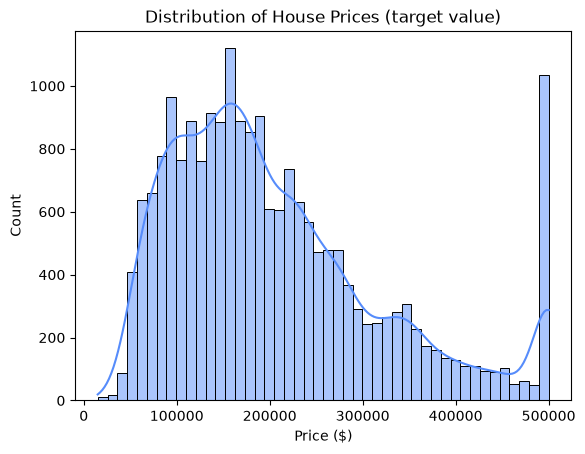

In [4]:
# distribution of house prices
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['median_house_value'], bins="auto", kde=True)
plt.title('Distribution of House Prices (target value)')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

We can see an anomaly at the 500k mark, with many houses priced at 500k, but very few priced at the levels before 500k. This could be because the dataset is capped at 500k and won't price houses at a higher price. This might be a problem for our model, as it cannot find some characteristics specific for a 500k house alone, because it also has to take into account characteristics of a 600k, 800k or 1M house. We could remove these rows for better results. 

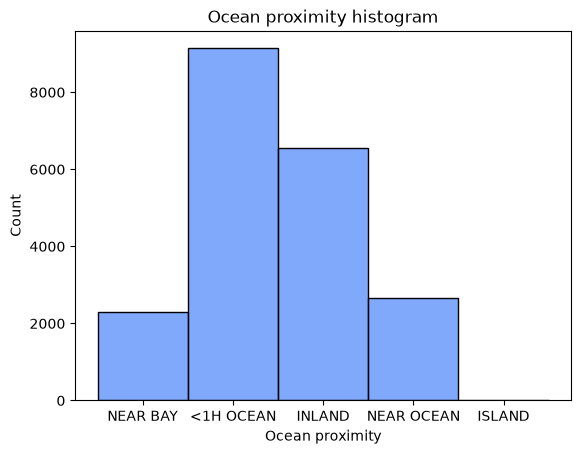

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [41]:
# living area histogram
sns.histplot(df['ocean_proximity'], bins="auto")
plt.title('Ocean proximity Bar Plot')
plt.xlabel('Ocean proximity')
plt.ylabel('Count')
plt.show()

print(df['ocean_proximity'].value_counts())

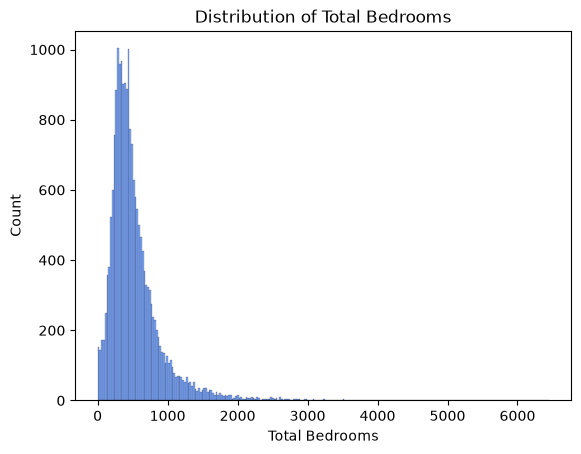

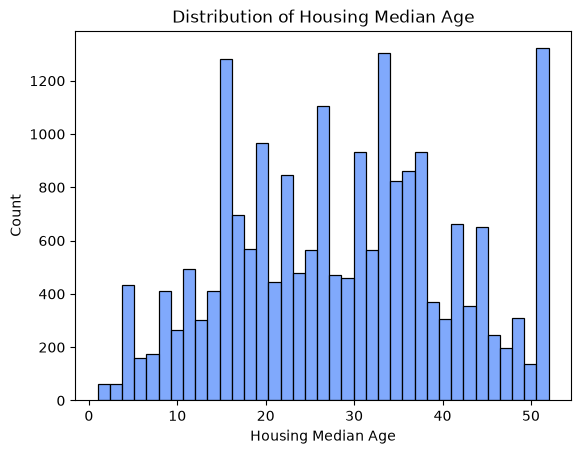

In [44]:
# distribution of number of bedrooms and year built
sns.histplot(df['total_bedrooms'], bins="auto")
plt.title('Distribution of Total Bedrooms')
plt.xlabel('Total Bedrooms')
plt.ylabel('Count')
plt.show()

sns.histplot(df['housing_median_age'], bins="auto")
plt.title('Distribution of Housing Median Age')
plt.xlabel('Housing Median Age')
plt.ylabel('Count')
plt.show()

There seem to be a few outliers in the target variable, with some houses being priced at over $500k. We can also see that most of the houses are located far from the ocean, and that there are a few neighborhoods with a very high number of bedrooms (over 10k). The median age of the houses is around 30 years, with a few houses being over 50 years old. Now let's compare some features with the target variable to see if we can find any correlations.

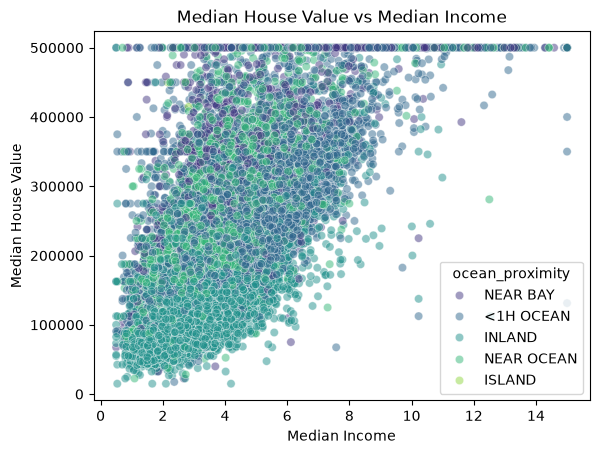

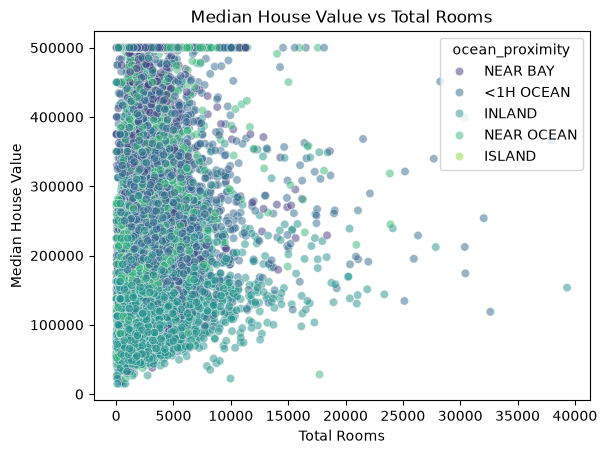

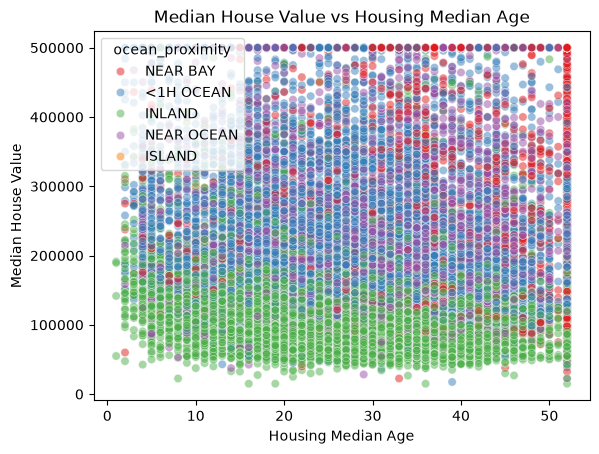

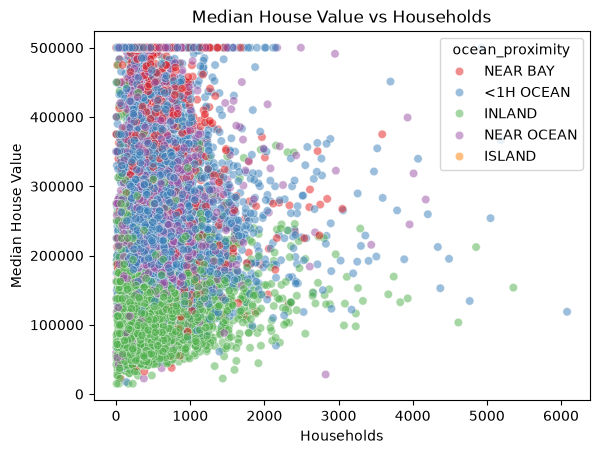

In [49]:
# scatter plot of median_house_value vs median_income
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title('Median House Value vs Median Income')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

# scatter plot of median_house_value vs total_rooms
sns.scatterplot(x='total_rooms', y='median_house_value', data=df, alpha=0.5, hue='ocean_proximity', palette='viridis', legend='full')
plt.title("Median House Value vs Total Rooms")
plt.xlabel("Total Rooms")
plt.ylabel("Median House Value")
plt.show()

# scatter plot of median_house_value vs housing_median_age
sns.scatterplot(x='housing_median_age', y='median_house_value', data=df, alpha=0.5, hue='ocean_proximity', palette='Set1', legend='full')
plt.title("Median House Value vs Housing Median Age")
plt.xlabel("Housing Median Age")
plt.ylabel("Median House Value")
plt.show()

# scatter plot of median_house_value vs households
sns.scatterplot(x='households', y='median_house_value', data=df, alpha=0.5, hue='ocean_proximity', palette='Set1', legend='full')
plt.title("Median House Value vs Households")
plt.xlabel("Households")
plt.ylabel("Median House Value")
plt.show()

Some of these charts offer an interesting insight on the relationship between two variables. For example:
- inland houses tend to be cheaper than houses close to the ocean, which are cheaper than houses near the bay. This is a clear indication that the ocean_proximity feature is important for predicting house prices.
- there is a clear correlation between median_income and median_house_value, with higher income neighborhoods having higher house prices. This is expected, as people with higher income can afford more expensive houses.
- some newer houses (<15 years) tend to be not as expensive as older houses
- the graph depicting the number of rooms vs price doesn't show any interesting information

## Chapter 3: Relationships & Insights

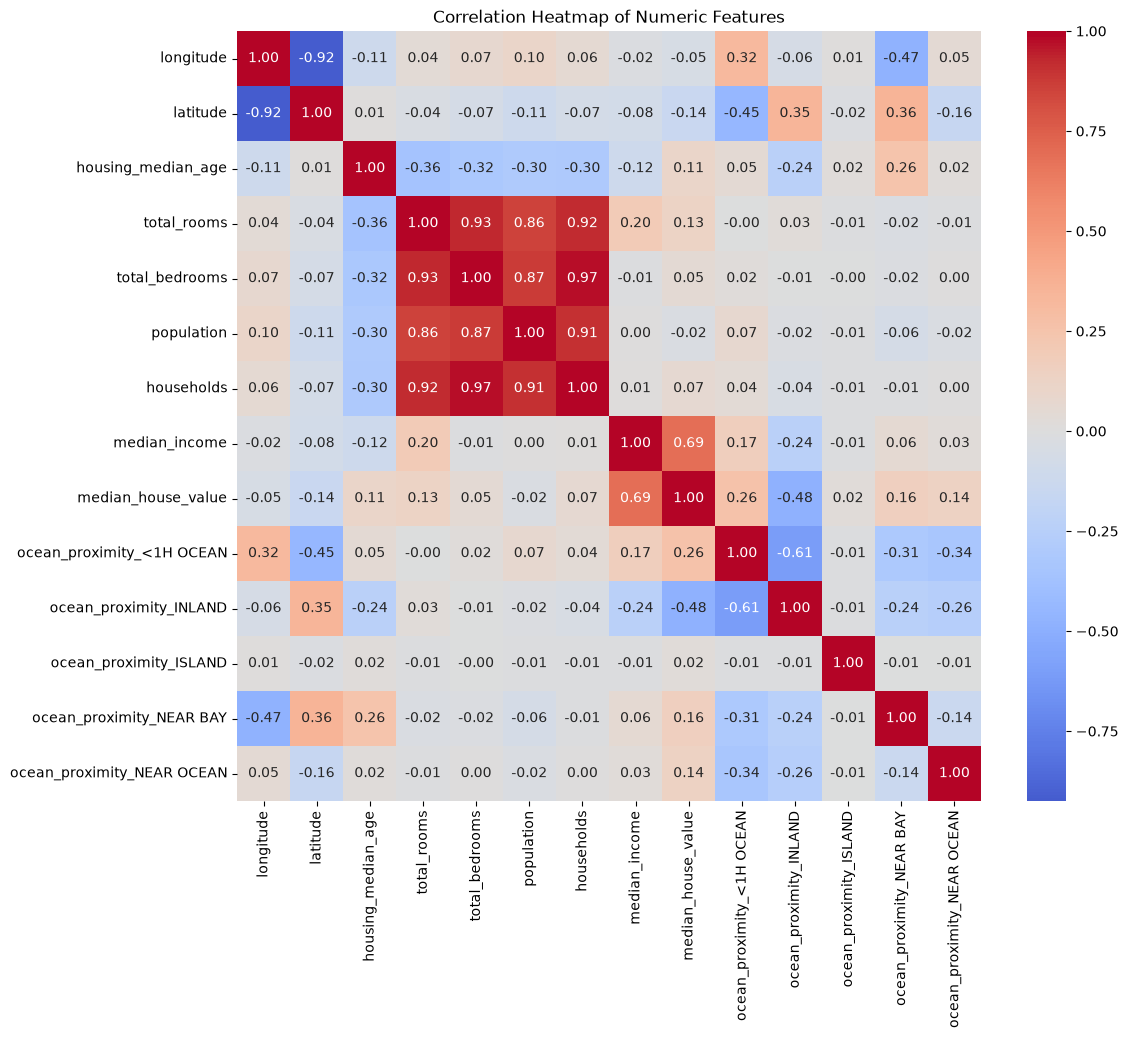

In [5]:
# firstly, encode the ocean_proximity feature using one-hot encoding
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
else:
    # already encoded or missing; detect dummy columns
    encoded_cols = [c for c in df.columns if c.startswith('ocean_proximity_')]
    if len(encoded_cols) > 0:
        print('ocean_proximity already encoded; found dummy columns:', encoded_cols)
    else:
        print("Warning: 'ocean_proximity' column not found and no dummy columns detected.\nMake sure you are using the original dataset or reload it before encoding.")

# convert any boolean dummy columns to integers so correlations are numeric
bool_cols = df.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    df[bool_cols] = df[bool_cols].astype(int)

# select numeric columns only for the correlation matrix
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

# show the correlation matrix between numeric attributes
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


From this correlation matrix we can find some features that exhibit a moderate (>0.5) or strong (0.7) correlation with the target variable (price):
- median_income (0.69), as previously discussed
- ocean_proximity_inland (-0.48), suggesting that inland houses are cheaper. We have talked about this before
Other features have a weak correlation with the target variable, but it is worth looking at the correlation between features themselves, as some of them are highly correlated with each other. For example:
- total rooms, bedrooms, population and households have a high correlation, which is expected, as they are all related to the size of the neighborhood; we can use this information to create a new features that resembles all 4 of them, reducing the size of the dataset
- longitude vs latitude: as California is more or less a 45 degree slope it makes sense that going south (lower latitude) you have to go east (higher longitude) to remain in California, otherwise you end up in the ocean. The longitude also has a moderate negative correlation with the near_bay ocean_proxmity
- there is also the negative correlation between <1h_ocean and inland, which is expected, as they are mutually exclusive.

Now let's look at a map of California, the housing prices and the closeness to some of the biggest cities:


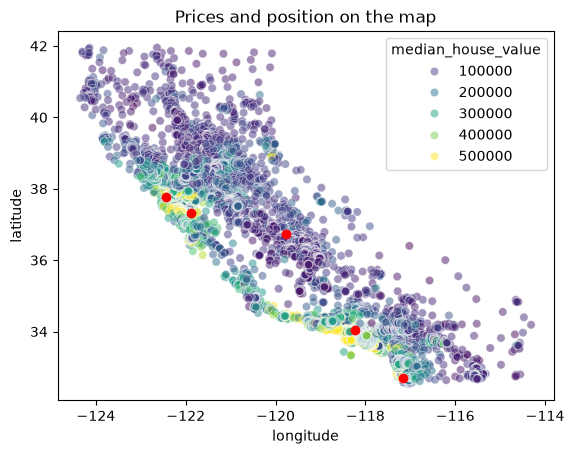

In [13]:
# plot the houses according to their coordinates
sns.scatterplot(x='longitude', y='latitude', data=df, alpha=0.5, hue='median_house_value', palette='viridis')

# add the top 5 biggest cities
plt.scatter(x=-118.24, y=34.05, color='r')  # Los Angeles
plt.scatter(x=-117.16, y=32.71, color='r')  # San Diego
plt.scatter(x=-121.89, y=37.33, color='r')  # San Jose
plt.scatter(x=-122.43, y=37.77, color='r')  # San Francisco
plt.scatter(x=-119.77, y=36.74, color='r')  # Fresno

plt.title("Prices and position on the map")
plt.show()

It is clear that being closer to some of the biggest cities in the state increases the value of the homes. We can see that houses priced above 400k (nearing the 500k range) are present almost only near the coast and close to the biggest 4 urban centers. The fifth-largest city (Fresno) is not associated with high housing costs so we'll drop it in future correlations. This shows that we can create a metric called "distance_to_city" which takes the smallest distance between the position of the neighborhood and the closest big city.

## Chapter 4: Feature Engineering & Feature Selection

Throughout the analysis phase we have identified some good correlations between the price and other features; however we have also identified some features that are repetitive and others that are waiting to be discovered (like the proximity to a big city in California). These are the features that we are going to create and test:
- rooms_per_household: measures the average house size, by creating a ratio between the number of rooms in a neighborhood and the number of homes
- bedrooms_per_room: measures house composition, a ratio between total bedrooms and total rooms
- population_per_household: measures how crowded households are
- distance_to_city: computes how far away the closest big city is by using the Euclidean distance
- total_house_age: computes the total age 'lived' by all the homes in that neighborhood (housing_median_age * households); experimental feature
- we have seen that the features that indicate the size of the neighborhood are highly correlated (which is expected) and may be dropped if the model becomes too big or the dataset too large
- by computing the distance_to_city we can also drop the latitude and longitude features, as they have a negligible correlation with the house price

In [5]:
from math import sqrt
# create a helper function for the distance_to_city metric
def compute_distance(lat, lon) -> float:
    cities = [(-118.24, 34.05), (-117.16, 32.71), (-121.89, 37.33), (-122.43, 37.77)]
    all_distances = []
    for city in cities:
        distance = sqrt((lon - city[0]) ** 2 + (lat - city[1]) ** 2)
        all_distances.append(distance)
    return min(all_distances)

# add the 5 metrics discussed above
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['distance_to_city'] = df.apply(lambda row: compute_distance(row['latitude'], row['longitude']), axis=1)
df['total_house_age'] = df['households'] * df['housing_median_age']

Now that we have created the features, we are going to test them by drawing some correlation histograms against the household price

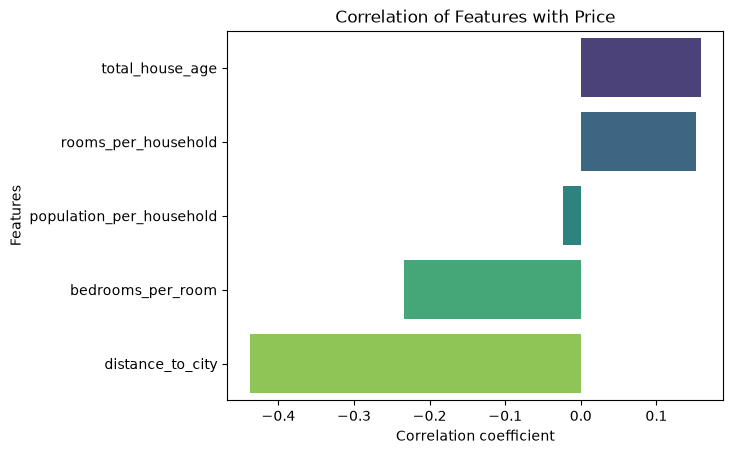

In [30]:
new_features = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'distance_to_city', 'total_house_age']

price_corr = df[new_features + ['median_house_value']].corr()['median_house_value'].drop('median_house_value').sort_values(ascending=False)

plt.figure()
sns.barplot(x=price_corr.values, y=price_corr.index, palette='viridis', hue=price_corr.index)
plt.title('Correlation of Features with Price')
plt.xlabel('Correlation coefficient')
plt.ylabel('Features')
plt.show()

We can see that most of the engineered features show a very weak correlation with the household price, except for distance_to_city. I will go ahead and remove the unnecessary features.

In [6]:
# drop the engineered features
if 'total_house_age' in df.columns:
    df = df.drop(columns=['total_house_age', 'rooms_per_household', 'population_per_household', 'bedrooms_per_room'])

# here you can drop the repetitive columns. I choose to keep them, as not all ML models are burdened by them
# df = df.drop(columns=['longitude', 'latitude', 'population', 'total_rooms', 'total_bedrooms'])

## Chapter 5: Conclusions

We have found a few useful corelations between features and price:
- distance_to_city with a coefficient of 0.45
- median_income with a coefficient of 0.69
- proximity_to_ocean, with inland neighborhoods being the cheapest while near_bay are the most expensive ones

There are other interesting features that can be discovered about the dataset, however they are not useful in predicting the price.

Let's take one last look at our data, as we are going to re-read it, and we want to know what features we found to be important

In [11]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,distance_to_city
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0.228254
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0.228473
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0.206155
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0.196977
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0.196977
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2.172487
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2.108744
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2.054191
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,1.996923


# Part 2: choosing, training and testing a regression model

Firstly, there is a problem: in the original dataset we have about 200 missing values on total bedrooms. This is not a problem in itself, is only 1% of the whole data, but when we replaced that value with the median value we have used the mean of the whole dataset to replace the missing values; as we did this before a train-test split, training data could contain information from testing data, a data leakage problem. Because the size of the problem isn't that big, we won't redo the analysis; however, we have to read the data again, split it AND THEN replace the missing values with the median of the training set. Let's do it!

In [2]:
from sklearn.model_selection import train_test_split

# read the data again
df = pd.read_csv('./dataset/housing.csv')

# drop prices that are at 500k, as they are some outliers to the norm
df = df[df['median_house_value'] < 495000]

# encode ocean_proximity
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

print("As you can see, we have null values again: ")
print(df.isnull().sum())

# split the data
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

# compute the median on the training set only
bedrooms_median = train_set['total_bedrooms'].median()

# fill missing values with the median
train_set['total_bedrooms'] = train_set['total_bedrooms'].fillna(bedrooms_median)
test_set['total_bedrooms'] = test_set['total_bedrooms'].fillna(bedrooms_median)

# re-add feature engineered columns
# create a helper function for the distance_to_city metric
def compute_distance(lat, lon) -> float:
    cities = [(-118.24, 34.05), (-117.16, 32.71), (-121.89, 37.33), (-122.43, 37.77)]
    all_distances = []
    for city in cities:
        distance = sqrt((lon - city[0]) ** 2 + (lat - city[1]) ** 2)
        all_distances.append(distance)
    return min(all_distances)

train_set['distance_to_city'] = df.apply(lambda row: compute_distance(row['latitude'], row['longitude']), axis=1)
test_set['distance_to_city'] = df.apply(lambda row: compute_distance(row['latitude'], row['longitude']), axis=1)

# from now, we have to use only train_set or test_set to visualize the data. df is no longer correct
train_set.head(10)

As you can see, we have null values again: 
longitude                       0
latitude                        0
housing_median_age              0
total_rooms                     0
total_bedrooms                200
population                      0
households                      0
median_income                   0
median_house_value              0
ocean_proximity_<1H OCEAN       0
ocean_proximity_INLAND          0
ocean_proximity_ISLAND          0
ocean_proximity_NEAR BAY        0
ocean_proximity_NEAR OCEAN      0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,distance_to_city
8059,-118.20,33.85,33.0,2557.0,731.0,2286.0,700.0,2.3041,149100.0,True,False,False,False,False,0.203961
3294,-122.65,38.99,16.0,4279.0,951.0,1596.0,666.0,1.8571,75900.0,False,True,False,False,False,1.239677
3102,-117.68,35.64,15.0,3253.0,573.0,1408.0,586.0,5.2043,95700.0,False,True,False,False,False,1.685734
10847,-117.91,33.67,32.0,3058.0,562.0,1475.0,569.0,4.4625,253500.0,True,False,False,False,False,0.503289
15291,-117.29,33.12,4.0,1380.0,322.0,755.0,286.0,4.7961,168800.0,False,False,False,False,True,0.430116
6999,-118.04,33.96,37.0,1948.0,395.0,1163.0,379.0,3.2250,154000.0,True,False,False,False,False,0.219317
3871,-118.54,34.21,22.0,6064.0,1826.0,4876.0,1697.0,2.8750,227100.0,True,False,False,False,False,0.340000
18947,-122.00,38.28,3.0,7030.0,1191.0,3238.0,1055.0,4.9620,161700.0,False,True,False,False,False,0.667083
8300,-118.14,33.76,50.0,914.0,167.0,322.0,165.0,4.7361,418800.0,False,False,False,False,True,0.306757
13994,-116.99,34.88,23.0,6060.0,1165.0,2920.0,1072.0,3.1528,69000.0,False,True,False,False,False,1.500467


## Chapter 1: choose a few models

I am going to use Gradient Boosting again, as I want to compare it with the other notebook. We will also go with a simpler linear regression to see how an advanced model compares to a basic one.

In [7]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

gb = GradientBoostingRegressor(random_state=42)
lr = LinearRegression()
pr = Pipeline([('poly', PolynomialFeatures(include_bias=False)), ('scaler', StandardScaler()), ('linear', LinearRegression())])

## Chapter 2: cross-validation

We are going to use K-Fold validation to find the best hyperparameters for the models and see which is the better one for this task

In [4]:
from sklearn.model_selection import KFold, cross_val_score

# initialize KFold algorithm
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# split the data
X_train = train_set.drop(columns=['median_house_value'])
y_train = train_set['median_house_value']

X_test = test_set.drop(columns=['median_house_value'])
y_test = test_set['median_house_value']

In [10]:
# hyperparameter search for Gradient Boosting; this trains 135 models
# Best GB params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
# Best GB CV MAE (with the whole data price range):  31055.9464
# Best GB CV MAE (with data prices capped at 495k, removing the anomalies at 500k): 28505.9817
# train time (on best performance laptop power settings): 2m 22
from sklearn.model_selection import GridSearchCV

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.05, 0.01],
    'max_depth': [3, 4, 5]
}

gb_grid = GridSearchCV(gb, gb_params, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

gb_grid.fit(X_train, y_train)

print("Best GB params: ", gb_grid.best_params_)
print("Best GB CV MAE: ", -gb_grid.best_score_)

Best GB params:  {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Best GB CV MAE:  28505.981768198624


In [21]:
# cross-validation for linear regression. Even though Linear Regression doesn't have hyperparameters to be tuned, we can still cross-validate it to find an MAE used for comparing models between them
# I will also compare linear regression with the raw data and the one that was engineered
# Linear Regression CV MAE: 49413.1890
from sklearn.model_selection import cross_val_score

# train on engineered data first
lr_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

# train on raw data. For this, we have to read again the data and drop the columns that cannot be encoded
raw_data = pd.read_csv('./dataset/housing.csv')
raw_data = raw_data.drop(columns=['ocean_proximity']) # ocean_proximity is the only categorical feature

# split the data again
raw_train_set, raw_test_set = train_test_split(raw_data, test_size=0.2, random_state=42)
raw_train_X = raw_train_set.drop(columns=['median_house_value'])
raw_train_y = raw_train_set['median_house_value']

raw_lr_scores = cross_val_score(lr, raw_train_X, raw_train_y, cv=kf, scoring='neg_mean_absolute_error') # test again

print("Linear Regression CV MAE with raw data: ", -raw_lr_scores.mean())
print("Linear Regression CV MAE with engineered data: ", -lr_scores.mean())

Linear Regression CV MAE with raw data:  50674.0310891166
Linear Regression CV MAE with engineered data:  43636.23605522705


As you can see, engineered data (encoding ocean_proximity, removing the anomalies at 500k and introducing features such as distance_to_city) helps even a simple model like linear regression to perform better.

In [14]:
# cross-validation for polynomial regression. We are going to trea the degree of the polynomial as a hyperparameter to be tuned
# Best PR params:  {'poly__degree': 3}
# Best PR CV MAE (with data capped at 495k house price):  35514.588335493085
# train time (on best performance laptop power settings): 1m

pr_params = { 'poly__degree': [1, 2, 3]}

pr_grid = GridSearchCV(pr, pr_params, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)

pr_grid.fit(X_train, y_train)

print("Best PR params: ", pr_grid.best_params_)
print("Best PR CV MAE: ", -pr_grid.best_score_)

Best PR params:  {'poly__degree': 3}
Best PR CV MAE:  35514.588335493085


In [12]:
# cross-validation for a dummy model. I am using this just to check if our models are actually better than just using the mean to predict the prices
# Dummy Regressor CV MAE: 91391.4745
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

dr_scores = cross_val_score(
    dummy,
    X_train,
    y_train,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Dummy Regressor CV MAE: ", -dr_scores.mean())

Dummy Regressor CV MAE:  77185.54870033667


In [15]:
# now we will compare the models between them, but firstly, let's see if they are meaningfully better than the dummy regressor:
gb_improvement = (-dr_scores.mean() + gb_grid.best_score_) / (-dr_scores.mean()) * 100
lr_improvement = (-dr_scores.mean() + lr_scores.mean()) / (-dr_scores.mean()) * 100
pr_improvement = (-dr_scores.mean() + pr_grid.best_score_) / (-dr_scores.mean()) * 100

print(f"Improvement for Gradient Boosting: {gb_improvement:.2f}%")
print(f"Improvement for Linear Regression: {lr_improvement:.2f}%")
print(f"Improvement for Polynomial Regression: {pr_improvement:.2f}%")

# now, compare the models
gb_best_mae = -gb_grid.best_score_
lr_best_mae = -lr_scores.mean()
pr_best_mae = -pr_grid.best_score_
best_model = None

if gb_best_mae == min(gb_best_mae, lr_best_mae, pr_best_mae):
    print("Gradient Boosting is the best model")
    best_model = GradientBoostingRegressor(**gb_grid.best_params_, random_state=42)
elif lr_best_mae == min(gb_best_mae, lr_best_mae, pr_best_mae):
    print("Linear Regression is the best model")
    best_model = lr
elif pr_best_mae == min(gb_best_mae, pr_best_mae, lr_best_mae):
    print("Polynomial Regression is the best model")
    best_model = Pipeline([('poly', PolynomialFeatures(**pr_grid.best_params_, include_bias=False)), ('scaler', StandardScaler()), ('linear', LinearRegression())])

Improvement for Gradient Boosting: 63.07%
Improvement for Linear Regression: 43.47%
Improvement for Polynomial Regression: 53.99%
Gradient Boosting is the best model


We can see that all models yield a significantly better score than just using the mean to predict the house price, but we have a clear winner: Gradient Boosting, the more complex model, predicts prices better, as expected.

## Chapter 3: train the model

Now that we have a winner, we can train the model on the entire training set

In [16]:
if best_model is not None:
    best_model.fit(X_train, y_train)
    if isinstance(best_model, GradientBoostingRegressor):
        print("Finished training Gradient Boosting model")
    elif isinstance(best_model, LinearRegression):
        print("Finished training Linear Regression model")
    elif isinstance(best_model, Pipeline):
        print("Finished training Polynomial Regression model")
else:
    print("Model does not exist. Ensure that you created the models before!")

Finished training Gradient Boosting model


## Chapter 4: test the model and visualize the results

We are going to test the model on the test data (which hasn't been used so far) and look at more metrics to assess its true performance

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if best_model is not None:
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R﷿﷿: {r2:.3f}")
else:
    print("Model does not exist. Ensure that you created the models before!")

MAE: 31115.09
RMSE: 46989.07
R﷿﷿: 0.832


MAE (Mean Absolute Error) = 31115.09
On average, your model's predicted house prices are off by about $31,115 from the actual prices. This is a direct measure of average prediction error in the same units as price.

RMSE (Root Mean Squared Error) = 46989.07
RMSE penalizes larger errors more than MAE because it squares the errors before averaging. An RMSE of ~$47k that is noticeably higher than MAE suggests that the model occasionally makes larger mistakes.

R﷿﷿ (Coefficient of Determination) = 0.832
This means your model explains about 83.2% of the variance in car prices. The closer to 1, the better the model fits the data. Values over 0.8 are generally considered good, although some unexplained variability still remains

Compared to the Dummy Regressor, which achieved an MAE of approximately $91,000, the Gradient Boosting model reduces prediction error by roughly 66%, demonstrating that it successfully captures meaningful patterns in the housing data.


Next, we will look at some plots. Firstly, the predicted versus actual price. The red line in the middle is what a perfect model would have predicted. The purple line at is the mean of the prices, which is what the dummy regressor would have predicted

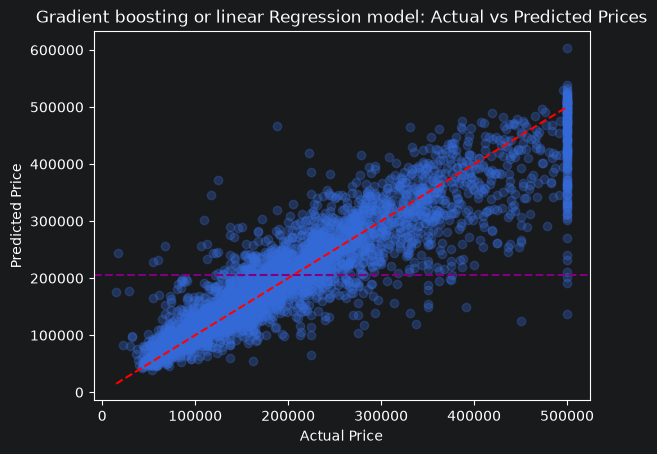

In [32]:
mean_price = y_test.mean()

plt.scatter(y_test, y_pred, alpha=0.3)
plt.axhline(y=mean_price, color="purple", linestyle="--", label=f"Mean price: {mean_price:.2f}")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient boosting or linear Regression model: Actual vs Predicted Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

It is visible that although the model identified the general trend, the predictions aren't perfect, with some variation. We see that the mean price is ~200k, making the MAE of 31k represent a 15% error. The largest errors are present right at the extreme, with actual prices of 500k. This could be a problem of the dataset, as more expensive houses are labeled as 500k becaues that is the upper limit, and thus the model cannot find a clear trend for 500k houses only.

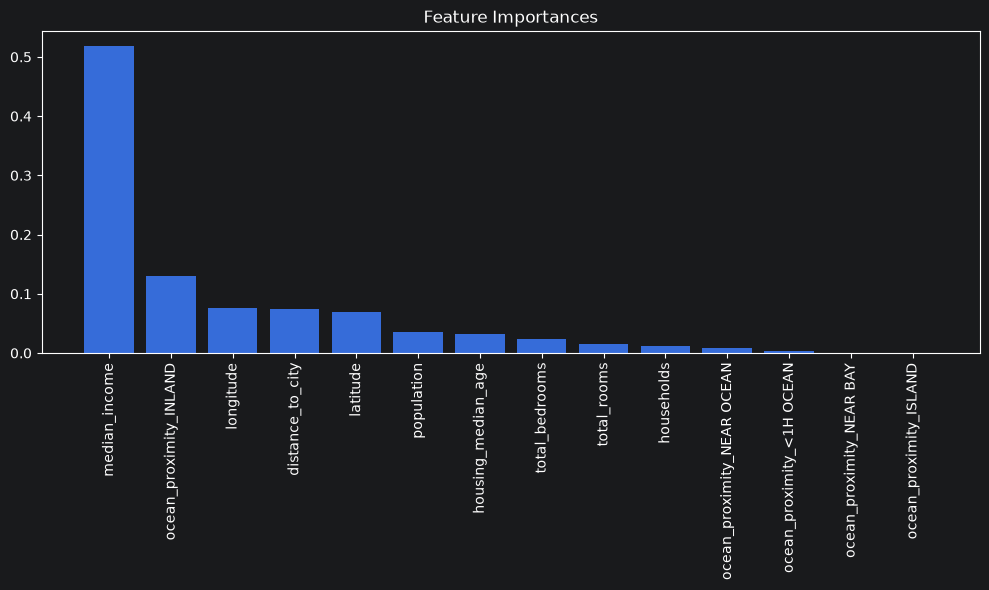

In [33]:
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()


This bar plot confirms what we have already intuited by looking at the correlation matrix: median_income is the most influential features, contributing to more than 50% of the model's total importance. Location features (longitude, distance_to_city etc.) and median_income contribute to more than 85% of the model's decision. Features such as households, total_rooms and inland proximity have low information and are rarely used, but they can sometimes refine a decision.

## Chapter 5: interpreting and limitations

### Interpreting
- the model managed to identify the general trend of the house value, but it is clear that it relies heavily on 2-3 features to make the predictions. The R^2 score of 0.832 supports this finding, that errors might still exist, including larger ones, as seen at the 500k price cap.
- the correlation matrix predicted fairly well which features are going to be the most important and which not. We could remove some for a ligher model, but it may not increase performance too much

### Limitations
- as we have seen in the dataset analysis part, there are a lot of houses priced at 500k, which could be the cap for this set. Because of this, more expensive houses, with different features, are priced at 500k as well, making it harder for the model to identify trends / characteristics of 500k neighborhoods.
- feature engineering was relatively simple, with only 5 metrics being generated, without trying to gather some meaningful insight (except distance_to_city)
- in order to save time, we have searched for only a few hyperparameters for each model. A more thorough search could improve the model's performance as we find the best combination of hyperparameters
- using other models might benefit us. We only tested linear regression, which is obviously not suited for a non-linear problem, and the base Gradient Boosting algorithm which also has improved versions like XGBoost